Per-size success_rate summary (mean ± SEM):
  size    type     n          mean           SEM
  0.6B    self     5      0.000000      0.000000
  0.6B   cross    33      0.090909      0.045926
  1.7B    self     6      0.000000      0.000000
  1.7B   cross    45      0.107037      0.039563
    4B    self     4      0.083333      0.083333
    4B   cross    37      0.218662      0.057355
    8B    self     4      0.500000      0.288675
    8B   cross    43      0.308306      0.065044
   14B    self     5      0.583333      0.200693
   14B   cross    47      0.453191      0.065448
   32B    self     5      0.960000      0.040000
   32B   cross    47      0.503901      0.067138
Saved summary CSV -> ./sem_summary_by_size.csv
Saved self-play chart -> ./sem_self_by_size.png
Saved cross-play chart -> ./sem_cross_by_size.png


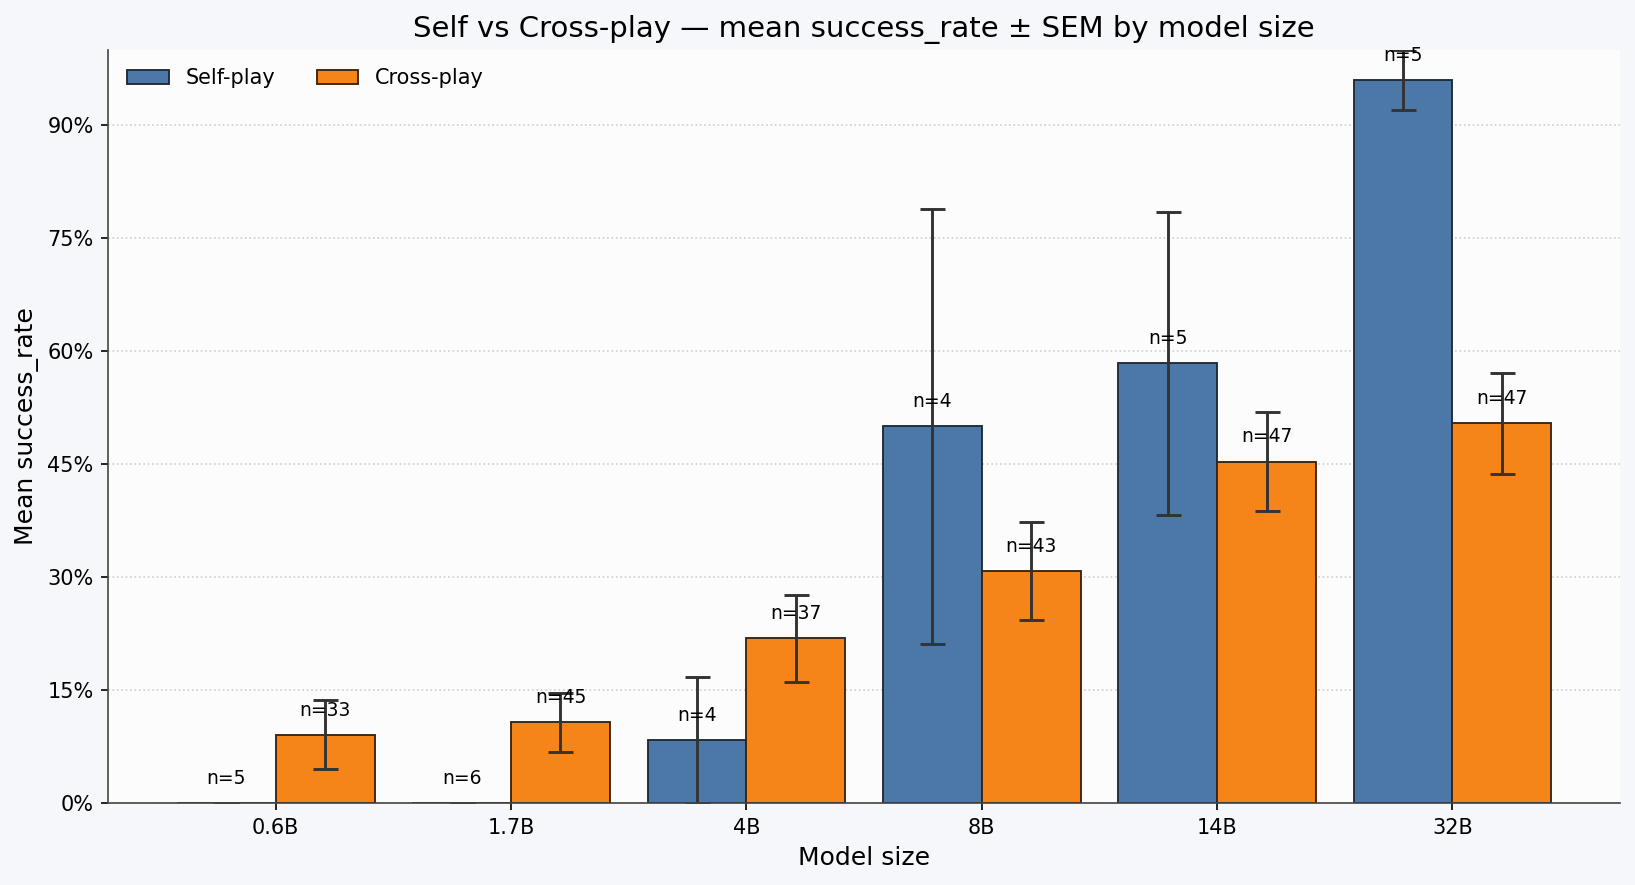

Saved combined chart -> ./sem_self_vs_cross_by_size.png


In [35]:
# NumPy + matplotlib (no pandas)
# Combined and styled chart for self-play vs cross-play SEMs by model size.
# Keeps your original summary + two separate charts (optional) and adds a third combined chart.

import os
import numpy as np
import csv
import re
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from collections import defaultdict

# ---------- Config ----------
INPUT_CANDIDATES = ["statistics_data_final-data-5.csv", "statistics_data_final-data-5.csv"]
OUT_DIR = "."
MAKE_SEPARATE = True  # set False to skip the two individual charts

# Distinct, readable colors
COLORS = {"self": "#4C78A8", "cross": "#F58518"}  # blue/orange, color-blind friendly-ish

# Style tweaks for a clean, modern look
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
})

# ---------- Helpers ----------
def find_path(cands):
    for p in cands:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find CSV at any of: {cands}")

def parse_pair(model_str):
    # Expect pattern like "Qwen_Qwen3-32B_Qwen_Qwen3-8B"
    parts = model_str.split("_")
    if len(parts) >= 4:
        a = parts[0] + "_" + parts[1]
        b = parts[2] + "_" + parts[3]
    else:
        mid = len(parts) // 2
        a = "_".join(parts[:mid])
        b = "_".join(parts[mid:])
    return a, b

_size_regex = re.compile(r'(\d+(?:\.\d+)?)\s*[Bb]\b')

def extract_size(label):
    # Try last hyphen token first (e.g., "Qwen3-32B" -> "32B")
    toks = label.split("-")
    for tok in reversed(toks):
        tok = tok.strip()
        if tok and (tok[-1] in "Bb"):
            m = _size_regex.match(tok)
            if m:
                num = m.group(1)
                return f"{num}B"
    # Fallback: search anywhere
    m = _size_regex.search(label)
    if m:
        return f"{m.group(1)}B"
    return None

def sem(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n <= 1:
        return float("nan")
    return float(np.std(x, ddof=1) / np.sqrt(n))

def size_key(sz):
    try:
        return float(sz[:-1])
    except Exception:
        return float("inf")

def polish_axes(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_facecolor("#FCFCFD")
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

def format_as_percent_if_applicable(ax, ymax_est):
    # If your success_rate is in [0,1], swap to % ticks.
    if np.isfinite(ymax_est) and ymax_est <= 1.05:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v*100:.0f}%"))
        ax.set_ylim(0, max(1.0, ymax_est))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

# ---------- Load ----------
path = find_path(INPUT_CANDIDATES)

# Collect success_rate values per size and play type
buckets = defaultdict(list)   # key = (size, play_type), value = list of success_rate
sizes_seen = set()

with open(path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            sr = float(row["success_rate"])
            model_str = row["model"]
        except (KeyError, ValueError):
            continue
        a, b = parse_pair(model_str)
        sa = extract_size(a)
        sb = extract_size(b)
        if sa is None or sb is None:
            continue
        sizes_seen.update([sa, sb])
        if sa == sb:
            buckets[(sa, "self")].append(sr)        # only once; same size both sides
        else:
            buckets[(sa, "cross")].append(sr)
            buckets[(sb, "cross")].append(sr)

sizes_sorted = sorted(sizes_seen, key=size_key)

# ---------- Summary (print + CSV) ----------
summary_rows = []
for sz in sizes_sorted:
    # self
    xs = np.array(buckets.get((sz, "self"), []), dtype=float)
    n_self = int(xs.size)
    mean_self = float(np.mean(xs)) if n_self else float("nan")
    sem_self = sem(xs) if n_self else float("nan")
    summary_rows.append((sz, "self", n_self, mean_self, sem_self))
    # cross
    xc = np.array(buckets.get((sz, "cross"), []), dtype=float)
    n_cross = int(xc.size)
    mean_cross = float(np.mean(xc)) if n_cross else float("nan")
    sem_cross = sem(xc) if n_cross else float("nan")
    summary_rows.append((sz, "cross", n_cross, mean_cross, sem_cross))

print("Per-size success_rate summary (mean ± SEM):")
print(f"{'size':>6}  {'type':>6}  {'n':>4}  {'mean':>12}  {'SEM':>12}")
for sz, typ, n, m, s in summary_rows:
    m_str = f"{m:.6f}" if not math.isnan(m) else "nan"
    s_str = f"{s:.6f}" if not math.isnan(s) else "nan"
    print(f"{sz:>6}  {typ:>6}  {n:4d}  {m_str:>12}  {s_str:>12}")

os.makedirs(OUT_DIR, exist_ok=True)
csv_out = os.path.join(OUT_DIR, "sem_summary_by_size.csv")
with open(csv_out, "w", newline="", encoding="utf-8") as g:
    w = csv.writer(g)
    w.writerow(["size", "type", "n", "mean_success_rate", "sem_success_rate"])
    for row in summary_rows:
        w.writerow(row)
print("Saved summary CSV ->", csv_out)

# ---------- (Optional) Individual charts ----------
error_kw = dict(ecolor="#333333", linewidth=1.3, capsize=6, capthick=1.3)

if MAKE_SEPARATE:
    # Self-play
    sizes_self = [sz for sz in sizes_sorted if buckets.get((sz, "self"))]
    means_self = [float(np.mean(buckets[(sz, "self")])) for sz in sizes_self]
    sems_self  = [sem(np.array(buckets[(sz, "self")], dtype=float)) for sz in sizes_self]

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor("#F6F7FB")
    x = np.arange(len(sizes_self))
    ax.bar(x, means_self, yerr=sems_self, color=COLORS["self"], edgecolor="#1f2a36", linewidth=0.9, error_kw=error_kw)
    ax.set_xticks(x, sizes_self)
    ax.set_ylabel("Mean success_rate")
    ax.set_title("Self-play: mean success_rate ± SEM by model size")
    polish_axes(ax)
    ymax = np.nanmax(np.array(means_self) + np.nan_to_num(np.array(sems_self), nan=0.0)) if len(means_self) else np.nan
    format_as_percent_if_applicable(ax, ymax)
    fig.tight_layout()
    self_png = os.path.join(OUT_DIR, "sem_self_by_size.png")
    fig.savefig(self_png)
    plt.close(fig)
    print("Saved self-play chart ->", self_png)

    # Cross-play
    sizes_cross = [sz for sz in sizes_sorted if buckets.get((sz, "cross"))]
    means_cross = [float(np.mean(buckets[(sz, "cross")])) for sz in sizes_cross]
    sems_cross  = [sem(np.array(buckets[(sz, "cross")], dtype=float)) for sz in sizes_cross]

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor("#F6F7FB")
    x = np.arange(len(sizes_cross))
    ax.bar(x, means_cross, yerr=sems_cross, color=COLORS["cross"], edgecolor="#3a2412", linewidth=0.9, error_kw=error_kw)
    ax.set_xticks(x, sizes_cross)
    ax.set_ylabel("Mean success_rate")
    ax.set_title("Cross-play: mean success_rate ± SEM by model size")
    polish_axes(ax)
    ymax = np.nanmax(np.array(means_cross) + np.nan_to_num(np.array(sems_cross), nan=0.0)) if len(means_cross) else np.nan
    format_as_percent_if_applicable(ax, ymax)
    fig.tight_layout()
    cross_png = os.path.join(OUT_DIR, "sem_cross_by_size.png")
    fig.savefig(cross_png)
    plt.close(fig)
    print("Saved cross-play chart ->", cross_png)

# ---------- Combined, color-coded chart ----------
sizes_all = sizes_sorted  # show every size we've seen
means_self_all  = [float(np.mean(buckets[(sz, "self")]))  if buckets.get((sz, "self"))  else np.nan for sz in sizes_all]
sems_self_all   = [sem(np.array(buckets[(sz, "self")],  dtype=float)) if buckets.get((sz, "self"))  else np.nan for sz in sizes_all]
n_self_all      = [len(buckets.get((sz, "self"), [])) for sz in sizes_all]

means_cross_all = [float(np.mean(buckets[(sz, "cross")])) if buckets.get((sz, "cross")) else np.nan for sz in sizes_all]
sems_cross_all  = [sem(np.array(buckets[(sz, "cross")], dtype=float)) if buckets.get((sz, "cross")) else np.nan for sz in sizes_all]
n_cross_all     = [len(buckets.get((sz, "cross"), [])) for sz in sizes_all]

x = np.arange(len(sizes_all))
width = 0.42

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#F6F7FB")

# Estimate ymax for formatting (handles NaNs)
ymax_est = 0.0
if len(sizes_all):
    a = np.nan_to_num(np.array(means_self_all), nan=0.0) + np.nan_to_num(np.array(sems_self_all), nan=0.0)
    b = np.nan_to_num(np.array(means_cross_all), nan=0.0) + np.nan_to_num(np.array(sems_cross_all), nan=0.0)
    ymax_est = float(max(np.max(a) if a.size else 0.0, np.max(b) if b.size else 0.0))

error_kw = dict(ecolor="#333333", linewidth=1.4, capsize=6, capthick=1.4)
b1 = ax.bar(x - width/2, means_self_all,  width, yerr=sems_self_all,  label="Self-play",
            color=COLORS["self"],  edgecolor="#1f2a36", linewidth=0.9, error_kw=error_kw)
b2 = ax.bar(x + width/2, means_cross_all, width, yerr=sems_cross_all, label="Cross-play",
            color=COLORS["cross"], edgecolor="#3a2412", linewidth=0.9, error_kw=error_kw)

ax.set_xticks(x)
ax.set_xticklabels(sizes_all)
ax.set_xlabel("Model size")
ax.set_ylabel("Mean success_rate")
ax.set_title("Self vs Cross-play — mean success_rate ± SEM by model size")
polish_axes(ax)
format_as_percent_if_applicable(ax, ymax_est)
ax.legend(frameon=False, ncol=2)

# annotate sample sizes above bars
ymin, ymax = ax.get_ylim()
yrange = ymax - ymin
for rect, n in zip(b1, n_self_all):
    h = rect.get_height()
    if np.isfinite(h):
        ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)
for rect, n in zip(b2, n_cross_all):
    h = rect.get_height()
    if np.isfinite(h):
        ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
combined_png = os.path.join(OUT_DIR, "sem_self_vs_cross_by_size.png")
fig.savefig(combined_png)
plt.show()
print("Saved combined chart ->", combined_png)
